Data PreProcessing & Remove Outliers

In [3]:
import pandas as pd
import numpy as np

# Load dataset
dataset_path = 'House Dataset.xlsx'  # Ensure this path is correct
xls = pd.ExcelFile(dataset_path)
df = pd.read_excel(xls, sheet_name="Sheet1")

# Clean column names by stripping spaces and checking for hidden characters
df.columns = df.columns.str.strip()

# Step 1: Handling Missing Values
df['Floor area 2nd floor (m2)'] = df['Floor area 2nd floor (m2)'].fillna(df['Floor area 2nd floor (m2)'].median())
df['Freight'] = df['Freight'].fillna(df['Freight'].median())

# Step 2: Remove Outliers from the 'Price (SEK incl VAT)' column using IQR
Q1 = df['Price (SEK incl VAT)'].quantile(0.25)
Q3 = df['Price (SEK incl VAT)'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds to filter out outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out rows where the price is an outlier
df = df[(df['Price (SEK incl VAT)'] >= lower_bound) & (df['Price (SEK incl VAT)'] <= upper_bound)]

# Step 3: Convert Categorical Columns to Numeric
df['Delivery location'] = df['Delivery location'].astype("category").cat.codes

# Step 4: Normalize 'Snow zone' column properly
df['Snow zone'] = df['Snow zone'].astype(str).str.replace(",", ".")  # Replace commas with dots

# Handle cases where 'Snow zone' contains ranges (e.g., "2.0-2.5")
df['Snow zone'] = df['Snow zone'].str.extract(r'(\d+(\.\d+)?)')[0]  # Extract first numeric value
df['Snow zone'] = pd.to_numeric(df['Snow zone'], errors='coerce')  # Convert to numeric

# Step 5: Save the Preprocessed Dataset
preprocessed_file_path = "Preprocessed_House_Dataset.xlsx"
df.to_excel(preprocessed_file_path, index=False)

# Display first few rows of the preprocessed data
print("\n Data Preprocessing Complete. First few rows of the dataset:")
print(df.head())



 Data Preprocessing Complete. First few rows of the dataset:
             Villa Name  Wall area (m2)  Inner walls area (m2)  \
0     Vladimir(Villa 1)              80                      0   
1       All In(Villa 2)             270                     50   
2        Blidö(Villa 3)             272                     55   
3  Hosseinpour(Villa 4)             207                     25   
4    Håkansson(Villa 5)             100                     25   

   Roof area (m2)  Floor area 2nd floor (m2)  Delivery location  Freight  \
0             185                        0.0                  2  35000.0   
1             110                       72.0                  0  25000.0   
2             158                       77.0                 11  55000.0   
3             185                      128.0                  4  35000.0   
4             140                        0.0                 14  20000.0   

   Number of windows std size  Number of windows >18 height  \
0                    

Exploratory Data Analysis

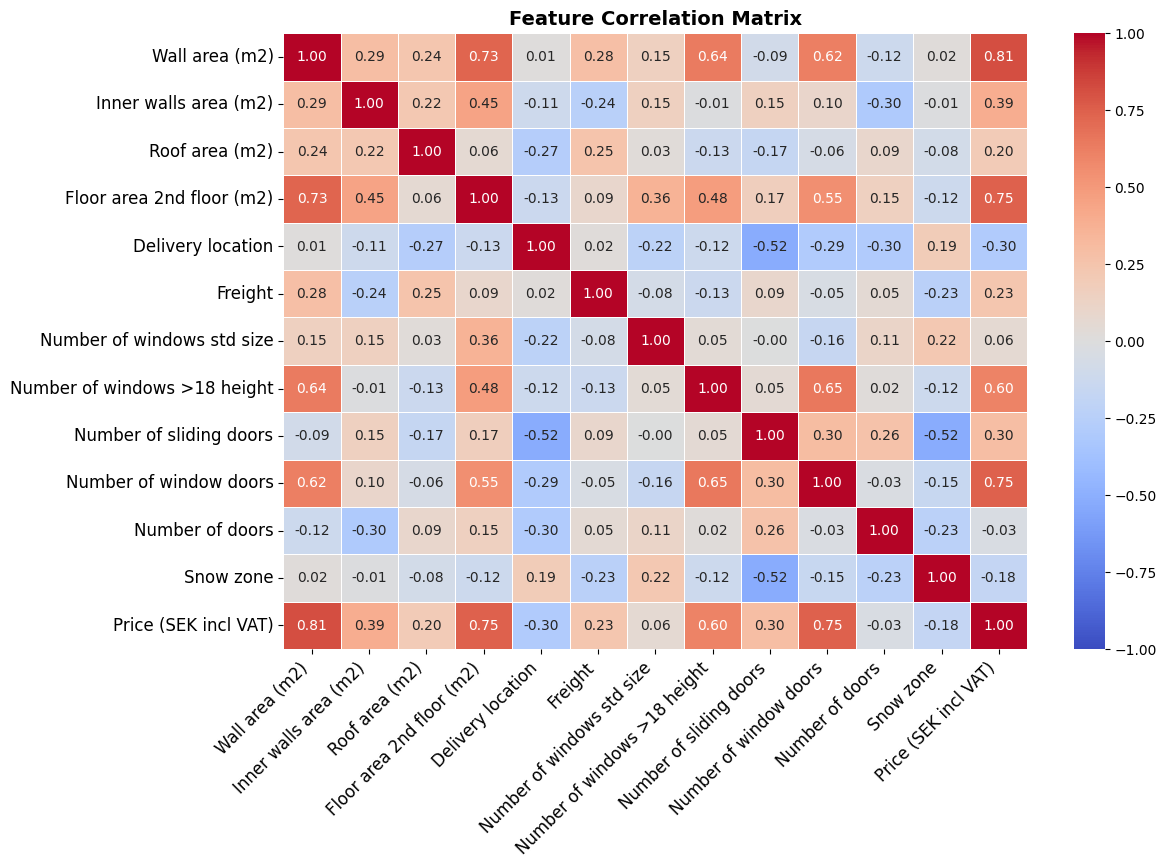

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix, handling NaN values
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,
            vmin=-1, vmax=1, annot_kws={"size": 10})  # Standardized color scale and improved annotations

# Rotate x and y labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')

plt.show()

Feature Engineering

In [5]:

# Load the preprocessed dataset
dataset_path = "Preprocessed_House_Dataset.xlsx"  # Update path if needed
df = pd.read_excel(dataset_path)

# Ensure column names are clean (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

# Step 1: Create New Features
df["Total House Area (m2)"] = df["Wall area (m2)"] + df["Roof area (m2)"]
df["Total Area (m2)"] = df["Wall area (m2)"] + df["Roof area (m2)"] + df["Floor area 2nd floor (m2)"]

# Step 2: Avoid division errors (handle zero values)
df["Wall-to-Roof Ratio"] = df["Wall area (m2)"] / df["Roof area (m2)"]
df.loc[df["Roof area (m2)"] == 0, "Wall-to-Roof Ratio"] = np.nan  # Avoid division by zero

df["Freight per m2"] = df["Freight"] / df["Total House Area (m2)"]
df.loc[df["Total House Area (m2)"] == 0, "Freight per m2"] = np.nan  # Avoid division by zero

# Check if "Price (SEK incl VAT)" column exists before proceeding
if "Price (SEK incl VAT)" in df.columns:
    df["Price per m2"] = df["Price (SEK incl VAT)"] / df["Total Area (m2)"]
    df.loc[df["Total Area (m2)"] == 0, "Price per m2"] = np.nan  # Avoid division by zero
else:
    print(" Warning: 'Price (SEK incl VAT)' column not found!")

# Step 3: Additional Feature Ratios
df["Window-to-Wall Ratio"] = (df["Number of windows std size"] + df["Number of windows >18 height"]) / df["Wall area (m2)"]
df.loc[df["Wall area (m2)"] == 0, "Window-to-Wall Ratio"] = np.nan  # Avoid division by zero

df["Door-to-Wall Ratio"] = (df["Number of sliding doors"] + df["Number of window doors"] + df["Number of doors"]) / df["Wall area (m2)"]
df.loc[df["Wall area (m2)"] == 0, "Door-to-Wall Ratio"] = np.nan  # Avoid division by zero

# Step 4: Normalize "Snow zone" (Using Z-score instead of Min-Max)
df["Snow zone Normalized"] = (df["Snow zone"] - df["Snow zone"].mean()) / df["Snow zone"].std()

# Step 5: Handle Missing Values in Numeric Columns Only
df.fillna(df.select_dtypes(include=[np.number]).median(), inplace=True)

# Step 6: Ensure No Inf Values Exist
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Step 7: Save the Feature-Engineered Dataset
feature_engineered_file_path = "Feature_Engineered_House_Dataset.xlsx"
df.to_excel(feature_engineered_file_path, index=False)

# Display completion message
print("\n Feature Engineering Complete. The updated dataset has been saved as 'Feature_Engineered_House_Dataset.xlsx'.")



 Feature Engineering Complete. The updated dataset has been saved as 'Feature_Engineered_House_Dataset.xlsx'.


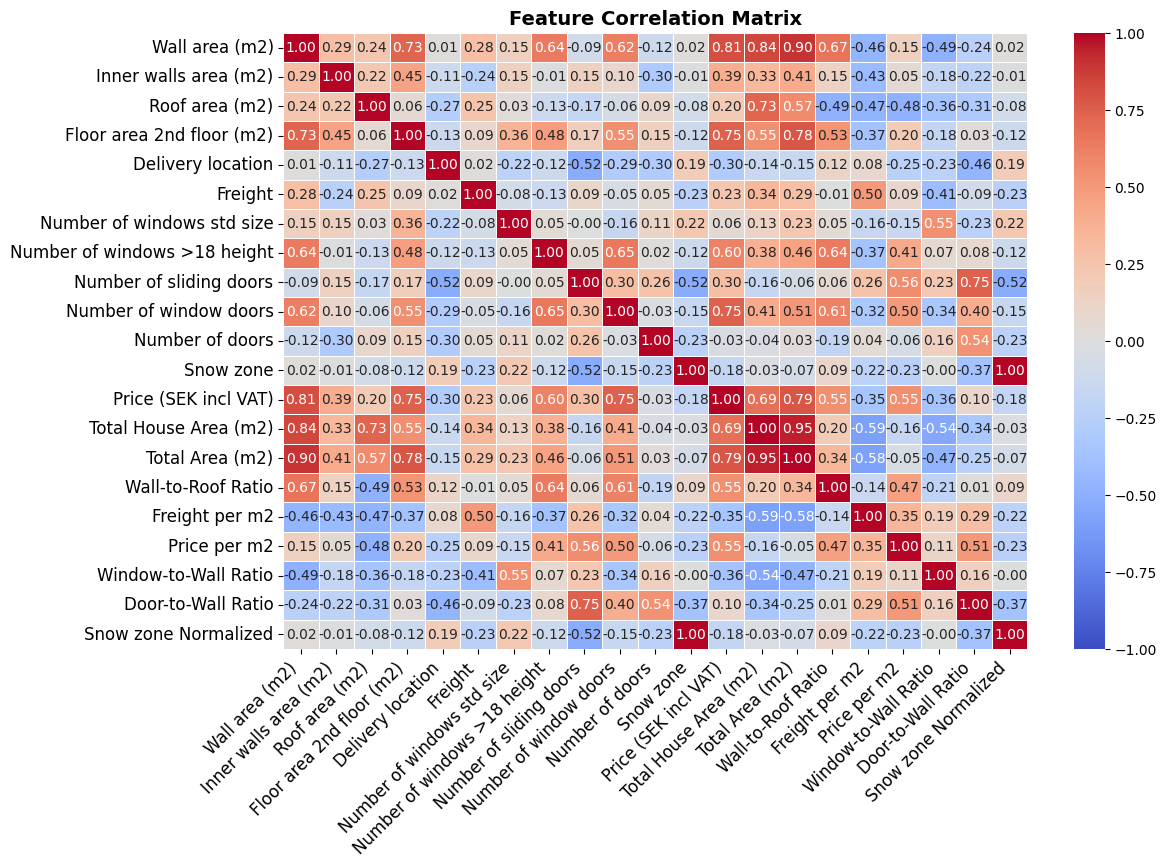

In [6]:
# Compute correlation matrix for numerical columns
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,
            vmin=-1, vmax=1, annot_kws={"size": 10})  # Standardized color scale and improved annotations

# Rotate x and y labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')

# Display the correlation heatmap

plt.show()

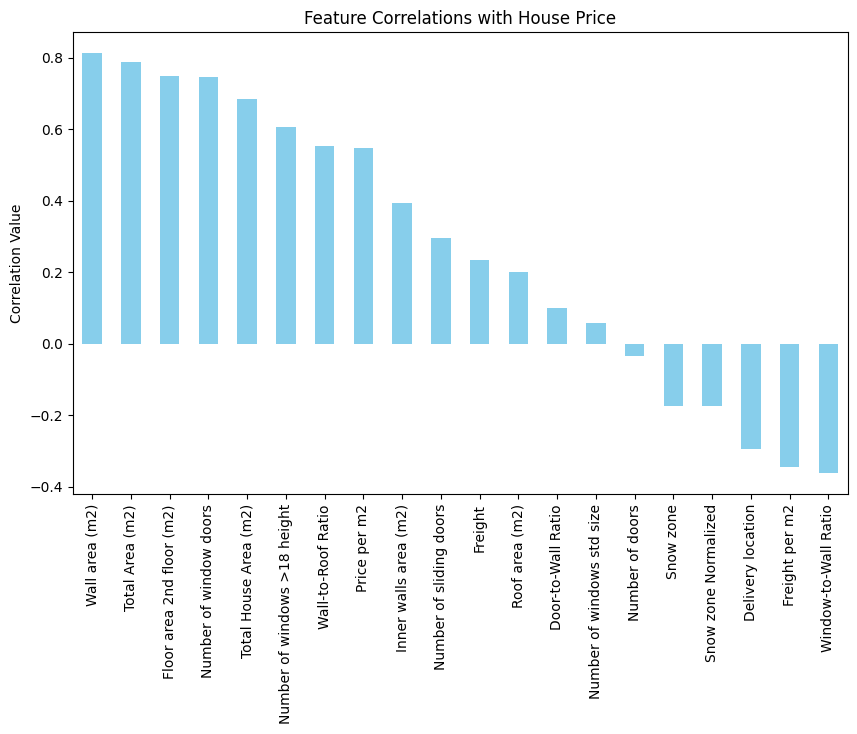

In [7]:
# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=[np.number])

# Calculate correlation with the target variable (Price)
correlations = numerical_cols.corr()['Price (SEK incl VAT)'].sort_values(ascending=False)

# Plot the top correlated features
plt.figure(figsize=(10, 6))
correlations.drop('Price (SEK incl VAT)').plot(kind='bar', color='skyblue')
plt.title("Feature Correlations with House Price")
plt.ylabel("Correlation Value")
plt.show()


Data Augumentation(Synthetic Data Generation)

In [8]:
# Import necessary libraries


# Load the feature-engineered dataset
original_dataset_path = "Feature_Engineered_House_Dataset.xlsx"  # Ensure correct path
df_original = pd.read_excel(original_dataset_path)

print(f" Original Dataset Loaded: {len(df_original)} rows")


best_noise_level = 0.02  # Optimal noise level (2%)
num_expansions = 10  # Number of synthetic copies to generate
df_expanded = df_original.copy()  # Start with original data

for _ in range(num_expansions):
    df_synthetic = df_original.copy()  # Create a copy of the original dataset

    
    numeric_cols = df_original.select_dtypes(include=[np.number]).columns
    noise = np.random.uniform(-best_noise_level, best_noise_level, size=df_synthetic[numeric_cols].shape)
    df_synthetic[numeric_cols] = df_synthetic[numeric_cols] * (1 + noise)

    
    for col in numeric_cols:
        min_val, max_val = df_original[col].min(), df_original[col].max()
        df_synthetic[col] = df_synthetic[col].clip(lower=min_val, upper=max_val)  # Prevent extreme values

    # Append synthetic data to the main dataset
    df_expanded = pd.concat([df_expanded, df_synthetic], ignore_index=True)

print(f" Dataset Expanded with Optimal Noise (±2%): {len(df_original)} → {len(df_expanded)} rows")

# Step 2: Ensure "Delivery location" Matches "Villa Name"
if "Villa Name" in df_original.columns and "Villa Name" in df_expanded.columns:
    villa_location_mapping = df_original.set_index("Villa Name")["Delivery location"].to_dict()

    # Assign correct delivery locations in the expanded dataset
    df_expanded["Delivery location"] = df_expanded["Villa Name"].map(villa_location_mapping)

# Fix FutureWarning: Ensure missing delivery locations are correctly filled
most_common_location = df_original["Delivery location"].mode()[0]
df_expanded.loc[df_expanded["Delivery location"].isna(), "Delivery location"] = most_common_location

# Step 3: Fix "Snow Zone" Column (Ensure Numeric & Valid Range)
if "Snow zone" in df_expanded.columns:
    df_expanded["Snow zone"] = df_expanded["Snow zone"].astype(str).str.replace(",", ".")  # Replace comma with dot
    df_expanded["Snow zone"] = df_expanded["Snow zone"].str.extract(r"(\d+\.?\d*)")[0]  # Extract numbers
    df_expanded["Snow zone"] = pd.to_numeric(df_expanded["Snow zone"], errors='coerce')  # Convert to float

    # Fix: Ensure "Snow zone" stays within valid range
    min_snow, max_snow = df_original["Snow zone"].min(), df_original["Snow zone"].max()
    df_expanded["Snow zone"] = df_expanded["Snow zone"].clip(lower=min_snow, upper=max_snow).round().astype(int)

# Step 4: Convert Integer-Like Columns to Whole Numbers
integer_columns = [
    "Number of windows std size", "Number of windows >18 height",
    "Number of sliding doors", "Number of window doors", "Number of doors"
]

for col in integer_columns:
    if col in df_expanded.columns:
        df_expanded[col] = df_expanded[col].round().astype(int)

# Step 5: Save the Final Cleaned and Expanded Dataset
expanded_dataset_path = "Final_Corrected_Expanded_House_Dataset.xlsx"
df_expanded.to_excel(expanded_dataset_path, index=False)



 Original Dataset Loaded: 22 rows
 Dataset Expanded with Optimal Noise (±2%): 22 → 242 rows


Evidence Of Expanded dataset 

 Original Dataset: 22 rows, 22 columns
 Expanded Dataset: 242 rows, 22 columns

 Summary Statistics - Original Dataset:
       Wall area (m2)  Inner walls area (m2)  Roof area (m2)  \
count       22.000000              22.000000       22.000000   
mean       171.136364              61.909091      169.045455   
std         72.449191              52.712074       57.455140   
min         67.000000               0.000000       75.000000   
25%        107.750000              25.000000      128.750000   
50%        161.000000              52.500000      167.000000   
75%        231.500000              88.250000      206.000000   
max        316.000000             182.000000      277.000000   

       Floor area 2nd floor (m2)  Delivery location       Freight  \
count                  22.000000           22.00000     22.000000   
mean                   39.863636            7.50000  33272.727273   
std                    50.572245            4.91596  11229.984600   
min                     0.0

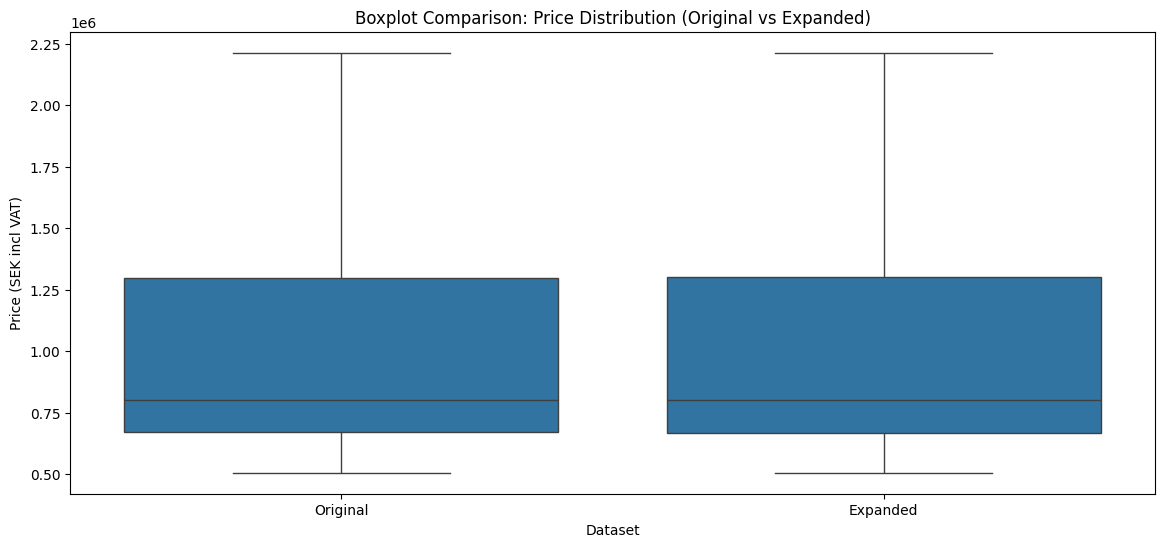

In [9]:
# Load datasets
original_dataset_path = "Feature_Engineered_House_Dataset.xlsx"
expanded_dataset_path = "Final_Corrected_Expanded_House_Dataset.xlsx"

df_original = pd.read_excel(original_dataset_path)
df_expanded = pd.read_excel(expanded_dataset_path)

# Step 1: Compare Dataset Sizes
print(f" Original Dataset: {df_original.shape[0]} rows, {df_original.shape[1]} columns")
print(f" Expanded Dataset: {df_expanded.shape[0]} rows, {df_expanded.shape[1]} columns")

# Step 2: Summary Statistics
summary_original = df_original.describe()
summary_expanded = df_expanded.describe()

print("\n Summary Statistics - Original Dataset:")
print(summary_original)

print("\n Summary Statistics - Expanded Dataset:")
print(summary_expanded)

# Step 3: Check for Missing Values
missing_values_original = df_original.isnull().sum()
missing_values_expanded = df_expanded.isnull().sum()

# Step 5: Boxplot Comparison for Outliers
plt.figure(figsize=(14, 6))
df_combined = pd.concat([
    df_original.assign(Dataset="Original"),
    df_expanded.assign(Dataset="Expanded")
])

sns.boxplot(x="Dataset", y="Price (SEK incl VAT)", data=df_combined)
plt.title("Boxplot Comparison: Price Distribution (Original vs Expanded)")
plt.show()



Feature Comparison between Original Vs Synthetic Data

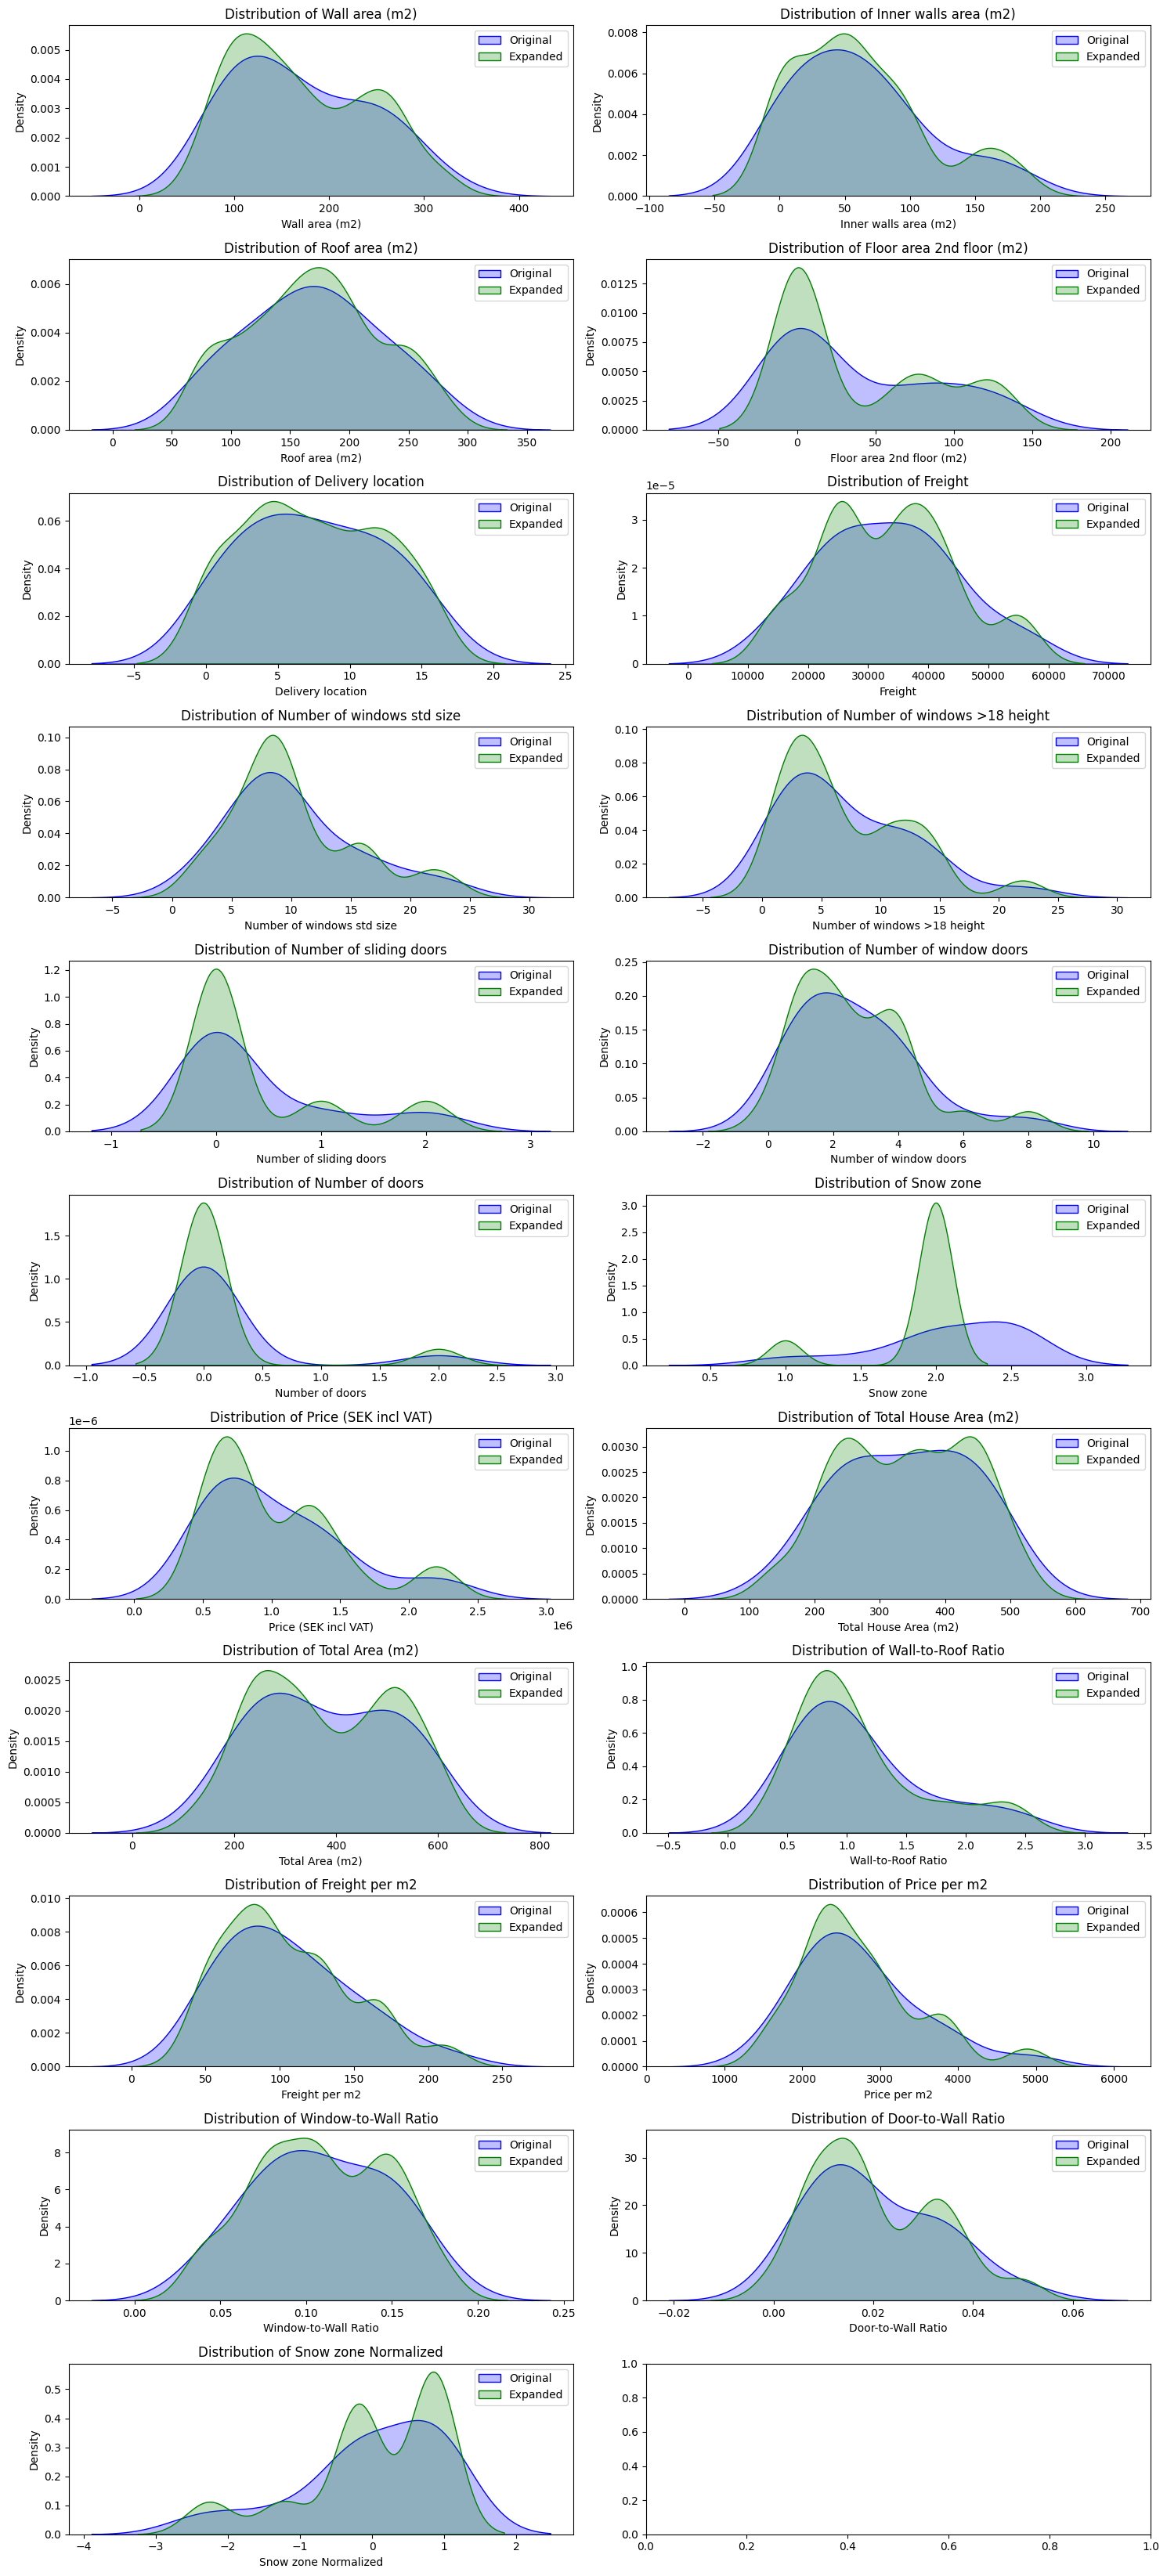

In [10]:
# Import necessary libraries


# Load datasets
original_dataset_path = "Feature_Engineered_House_Dataset.xlsx"
expanded_dataset_path = "Final_Corrected_Expanded_House_Dataset.xlsx"

df_original = pd.read_excel(original_dataset_path)
df_expanded = pd.read_excel(expanded_dataset_path)

# Select only numerical features for comparison
numeric_cols = df_original.select_dtypes(include=[np.number]).columns

# Create subplots
num_features = len(numeric_cols)
num_rows = (num_features // 2) + (num_features % 2)  # Arrange plots in 2 columns
fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows * 3))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(numeric_cols):
    sns.kdeplot(df_original[col], label="Original", fill=True, color="blue", ax=axes[i])
    sns.kdeplot(df_expanded[col], label="Expanded", fill=True, color="green", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].legend()

# Adjust layout
plt.tight_layout()
plt.show()


Train Test Split

In [11]:
# Step 1: Import Necessary Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 2: Load Dataset
dataset_path = "Final_Corrected_Expanded_House_Dataset.xlsx"  # Update path for your dataset
df = pd.read_excel(dataset_path)

# Step 3: Identify Categorical & Numerical Columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Ensure Target Variable is Present
target_col = "Price (SEK incl VAT)"
if target_col not in df.columns:
    raise ValueError(f"⚠️ Error: Target variable '{target_col}' not found in dataset!")

# Remove Target Variable from Numerical Columns
numerical_cols.remove(target_col)

# Step 4: Encode Categorical Columns Using Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert to string before encoding
    label_encoders[col] = le  # Save encoder for future use

# Step 5: Define Features (X) and Target Variable (y)
X = df.drop(columns=[target_col])  # Features
y = df[target_col]  # Target Variable

# Step 6: Split Data into Training (80%) and Testing (20%) Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Scale Only Numerical Features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Step 8: Save Encoders & Scaler for Future Use
import joblib
joblib.dump(scaler, "scaler.pkl")  # Save scaler
joblib.dump(label_encoders, "label_encoders.pkl")  # Save label encoders

# Step 9: Display Confirmation Message
print(" Data Preprocessing Completed Successfully!")
print(f" Training Set: {X_train_scaled.shape[0]} samples, Testing Set: {X_test_scaled.shape[0]} samples")
print(f" Feature Count: {X_train_scaled.shape[1]}")


 Data Preprocessing Completed Successfully!
 Training Set: 193 samples, Testing Set: 49 samples
 Feature Count: 21


Feature Selection (Find Most Important Features)

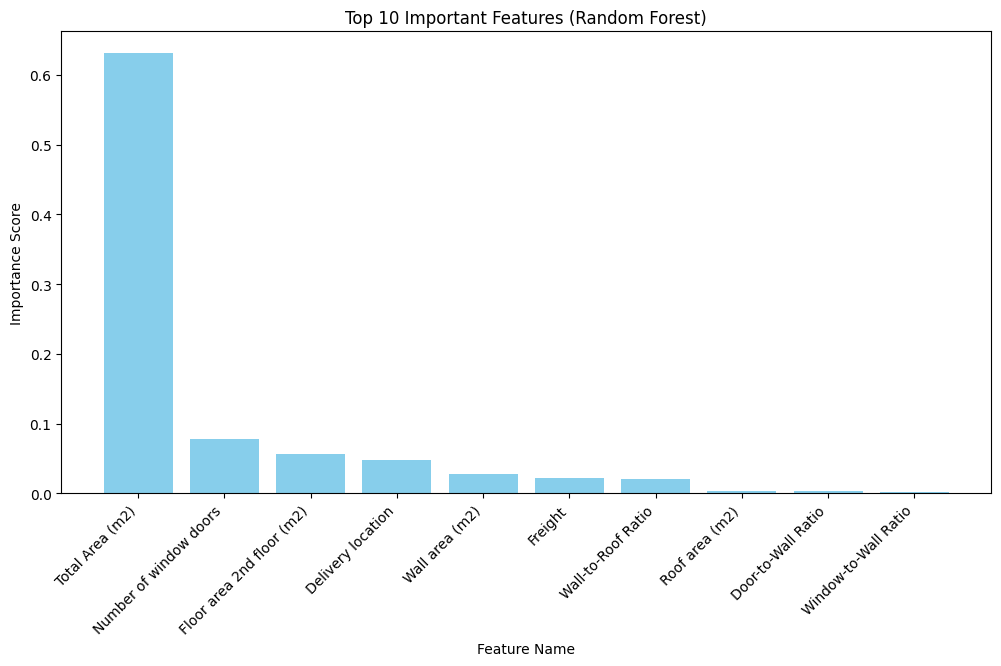


 Top 10 Important Features Selected: ['Total Area (m2)', 'Number of window doors', 'Floor area 2nd floor (m2)', 'Delivery location', 'Wall area (m2)', 'Freight', 'Wall-to-Roof Ratio', 'Roof area (m2)', 'Door-to-Wall Ratio', 'Window-to-Wall Ratio']


In [12]:
#from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
# Train a Temporary Random Forest Model to Get Feature Importances
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train_scaled, y_train)

# Get Feature Importance Scores
feature_importance = rf_temp.feature_importances_
feature_names = np.array(X_train_scaled.columns)  # Convert feature names to NumPy array

# Exclude Unwanted Features
exclude_features = ["Price per m2", "Villa Name"]
filtered_indices = [i for i, feature in enumerate(feature_names) if feature not in exclude_features]

# Select Only Relevant Features
filtered_feature_names = feature_names[filtered_indices]
filtered_importance = feature_importance[filtered_indices]

# Sort Features by Importance
sorted_indices = np.argsort(filtered_importance)[::-1]
sorted_features = filtered_feature_names[sorted_indices]
sorted_importance = filtered_importance[sorted_indices]

# Plot Feature Importance (Top 10 Features)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features[:10], sorted_importance[:10], color="skyblue")  # Top 10 Features
plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

#  Keep Only the Top 10 Features
top_features = sorted_features[:10].tolist()
print("\n Top 10 Important Features Selected:", top_features)



Train Models Using Selected Features

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#  Use Only Selected Features
X_train_selected = X_train_scaled[top_features]
X_test_selected = X_test_scaled[top_features]

#  Train Decision Tree Model
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_selected, y_train)
y_pred_dt = dt_model.predict(X_test_selected)

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_split=5, min_samples_leaf=3, random_state=42)
rf_model.fit(X_train_selected, y_train)
y_pred_rf = rf_model.predict(X_test_selected)

#  Train XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1, random_state=42)
xgb_model.fit(X_train_selected, y_train)
y_pred_xgb = xgb_model.predict(X_test_selected)

# Function to Evaluate Models
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n {model_name} Performance:")
    print(f" Mean Absolute Error (MAE): {mae:.2f}")
    print(f" Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f" R² Score: {r2:.4f}")
    
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

#  Compare All Models
results = []
results.append(evaluate_model(y_test, y_pred_dt, "Decision Tree"))
results.append(evaluate_model(y_test, y_pred_rf, "Random Forest"))
results.append(evaluate_model(y_test, y_pred_xgb, "XGBoost"))

#  Convert to DataFrame
results_df = pd.DataFrame(results)
print("\n Model Comparison Summary:")
print(results_df)



 Decision Tree Performance:
 Mean Absolute Error (MAE): 12399.53
 Root Mean Squared Error (RMSE): 16594.30
 R² Score: 0.9992

 Random Forest Performance:
 Mean Absolute Error (MAE): 10968.34
 Root Mean Squared Error (RMSE): 14637.65
 R² Score: 0.9994

 XGBoost Performance:
 Mean Absolute Error (MAE): 23118.91
 Root Mean Squared Error (RMSE): 49073.16
 R² Score: 0.9927

 Model Comparison Summary:
           Model           MAE          RMSE        R2
0  Decision Tree  12399.532610  16594.304682  0.999170
1  Random Forest  10968.344234  14637.650982  0.999354
2        XGBoost  23118.905861  49073.164383  0.992740


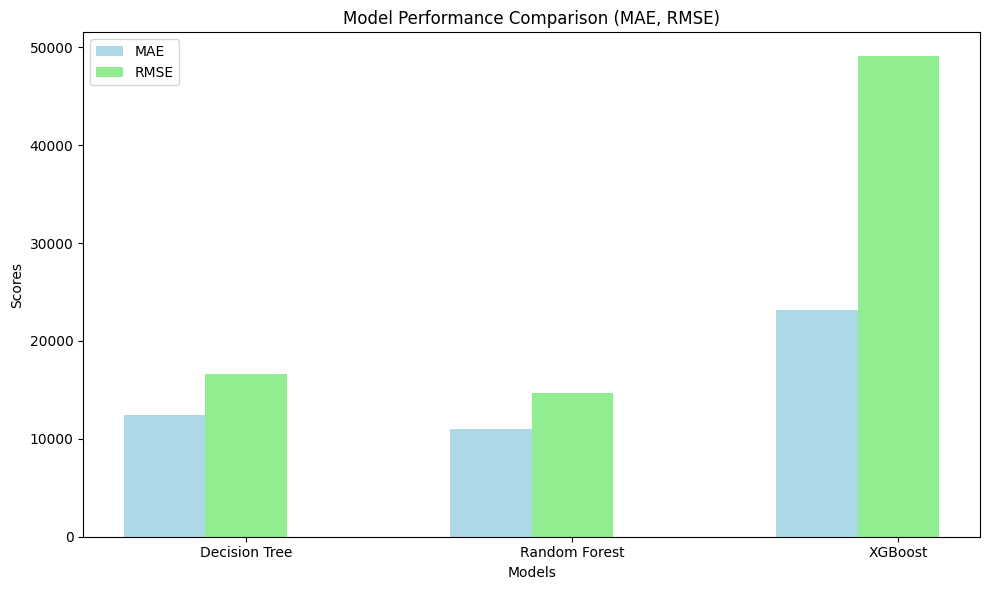

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Extracting MAE, RMSE, and R² values from the results DataFrame
mae = results_df['MAE']
rmse = results_df['RMSE']
# r2 = results_df['R2']

# Model names for x-axis labels
models = results_df['Model']

# X-axis positions
x = np.arange(len(models))

# Bar width for each metric
bar_width = 0.25

# Create a figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot MAE, RMSE, and R² as bar charts
bar1 = ax.bar(x - bar_width, mae, bar_width, label='MAE', color='lightblue')
bar2 = ax.bar(x, rmse, bar_width, label='RMSE', color='lightgreen')
#bar3 = ax.bar(x + bar_width, r2, bar_width, label='R²', color='salmon')

# Labeling and aesthetics
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison (MAE, RMSE)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Display the bar chart
plt.tight_layout()
plt.show()


Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV

#  Define Hyperparameter Grid for Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

#  Define Hyperparameter Grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

#  Define Hyperparameter Grid for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5]
}

#  Perform Grid Search for Decision Tree
dt_grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
dt_grid_search.fit(X_train_selected, y_train)
best_dt = dt_grid_search.best_estimator_

#  Perform Grid Search for Random Forest
rf_grid_search = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_grid_search.fit(X_train_selected, y_train)
best_rf = rf_grid_search.best_estimator_

#  Perform Grid Search for XGBoost
xgb_grid_search = GridSearchCV(XGBRegressor(random_state=42), xgb_param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
xgb_grid_search.fit(X_train_selected, y_train)
best_xgb = xgb_grid_search.best_estimator_

#  Print Best Parameters
print("\n Best Decision Tree Parameters:", dt_grid_search.best_params_)
print(" Best Random Forest Parameters:", rf_grid_search.best_params_)
print(" Best XGBoost Parameters:", xgb_grid_search.best_params_)



 Best Decision Tree Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
 Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
 Best XGBoost Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'reg_alpha': 1.0, 'reg_lambda': 1.5, 'subsample': 0.8}


Cross-Validation on the Tuned Models

In [16]:
from sklearn.model_selection import cross_val_score

#  Function to Perform Cross-Validation
def cross_validate_model(model, X, y, model_name):
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    avg_score = -np.mean(scores)  # Convert negative score to positive
    print(f"\n {model_name} Cross-Validation MAE: {avg_score:.2f}")
    return avg_score

# Perform Cross-Validation on Tuned Models
dt_cv_score = cross_validate_model(best_dt, X_train_selected, y_train, "Tuned Decision Tree")
rf_cv_score = cross_validate_model(best_rf, X_train_selected, y_train, "Tuned Random Forest")
xgb_cv_score = cross_validate_model(best_xgb, X_train_selected, y_train, "Tuned XGBoost")

#  Compare Cross-Validation Results
cv_results = pd.DataFrame({
    "Model": ["Tuned Decision Tree", "Tuned Random Forest", "Tuned XGBoost"],
    "Cross-Val MAE": [dt_cv_score, rf_cv_score, xgb_cv_score]
})
print("\n Cross-Validation Results:")
print(cv_results)



 Tuned Decision Tree Cross-Validation MAE: 12231.97

 Tuned Random Forest Cross-Validation MAE: 12236.77

 Tuned XGBoost Cross-Validation MAE: 16564.25

 Cross-Validation Results:
                 Model  Cross-Val MAE
0  Tuned Decision Tree   12231.971367
1  Tuned Random Forest   12236.771612
2        Tuned XGBoost   16564.252115


Choose the best Model

In [17]:
#  Find the Model with Lowest MAE
best_model_name = cv_results.loc[cv_results["Cross-Val MAE"].idxmin(), "Model"]
print(f"\n Best Model After Tuning & Cross-Validation: {best_model_name}")

#  Save the Best Model
best_model = {"Tuned Decision Tree": best_dt, "Tuned Random Forest": best_rf, "Tuned XGBoost": best_xgb}[best_model_name]
import joblib
joblib.dump(best_model, "best_house_price_model.pkl")

print("\n Best Model Saved as 'best_house_price_model.pkl'")



 Best Model After Tuning & Cross-Validation: Tuned Decision Tree

 Best Model Saved as 'best_house_price_model.pkl'


Predict on the test set

In [18]:
import joblib

#  Load the Best Model
best_model = joblib.load("best_house_price_model.pkl")

#  Predict on the test set
y_pred_final = best_model.predict(X_test_selected)

#  Compute Prediction Differences
df_results = pd.DataFrame({
    "Actual Price (SEK)": y_test,
    "Predicted Price (SEK)": y_pred_final
})

# Calculate Absolute Difference
df_results["Absolute Difference (SEK)"] = abs(df_results["Actual Price (SEK)"] - df_results["Predicted Price (SEK)"])

# Calculate Percentage Difference
df_results["Percentage Difference (%)"] = (df_results["Absolute Difference (SEK)"] / df_results["Actual Price (SEK)"]) * 100

#  Save Results to Excel
df_results.to_excel("Final_House_Price_Predictions.xlsx", index=False)

#  Print Performance Metrics
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("\n Final Model Performance:")
print(f" Mean Absolute Error (MAE): {mae_final:.2f}")
print(f" Root Mean Squared Error (RMSE): {rmse_final:.2f}")
print(f" R² Score: {r2_final:.4f}")

#  Display Dataset with Actual vs. Predicted Prices
import pandas as pd
df_results.head()



 Final Model Performance:
 Mean Absolute Error (MAE): 10668.46
 Root Mean Squared Error (RMSE): 14467.19
 R² Score: 0.9994


,Actual Price (SEK),Predicted Price (SEK),Absolute Difference (SEK),Percentage Difference (%)
24,1.443581e+06,1.440655e+06,2926.452435,0.202722
6,7.741250e+05,7.800355e+05,5910.475898,0.763504
152,7.929794e+05,8.009177e+05,7938.327787,1.001076
209,7.250503e+05,7.141450e+05,10905.302328,1.504075
237,1.596796e+06,1.624723e+06,27926.717580,1.748922


In [19]:
#  Step 1: Import Necessary Libraries

from sklearn.preprocessing import StandardScaler, LabelEncoder

#  Step 2: Load Dataset
dataset_path = "Final_Corrected_Expanded_House_Dataset.xlsx"
df = pd.read_excel(dataset_path)

#  Step 3: Load the Best Model
model_path = "best_house_price_model.pkl"
best_model = joblib.load(model_path)

#  Step 4: Identify Categorical and Numerical Columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

#  Step 5: Encode Categorical Columns Using Label Encoding
label_encoders = {}  # Dictionary to store encoders
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Convert string values to numbers
    label_encoders[col] = le  # Save encoder for reference

#  Step 6: Ensure Features Used in Training Match the Data
expected_features = best_model.feature_names_in_  # Extract features from trained model
#X_selected = df[expected_features]  # Select matching features
X_selected = df[expected_features].copy()
#  Step 7: Scale Numerical Features to Match Training Data
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_selected)  # Standardizing the features
X_scaled = scaler.fit_transform(X_selected)
X_scaled = pd.DataFrame(X_scaled, columns=expected_features)

#  Step 8: Predict House Prices
df["Predicted Price (SEK)"] = best_model.predict(X_scaled)

#  Step 9: Compute Absolute and Percentage Differences
df["Absolute Difference (SEK)"] = abs(df["Price (SEK incl VAT)"] - df["Predicted Price (SEK)"])
df["Percentage Difference (%)"] = (df["Absolute Difference (SEK)"] / df["Price (SEK incl VAT)"]) * 100

#  Step 10: Save the Updated Dataset with Predictions
output_path = "Updated_House_Price_Predictions.xlsx"
df.to_excel(output_path, index=False)

print("\n Updated dataset saved successfully!")
print(f" File saved as: {output_path}")



 Updated dataset saved successfully!
 File saved as: Updated_House_Price_Predictions.xlsx


Plot of Actual vs. Predicted Prices

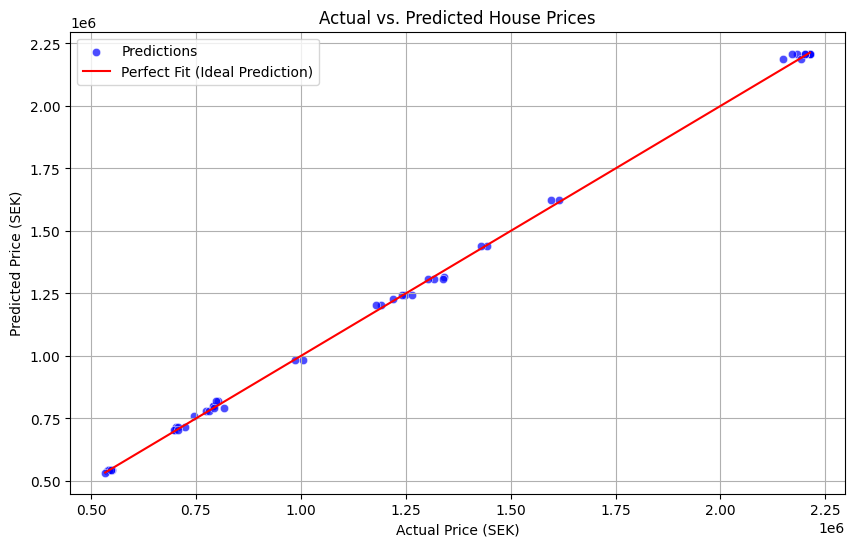

In [20]:


#  Create Scatter Plot of Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_results["Actual Price (SEK)"], y=df_results["Predicted Price (SEK)"], alpha=0.7, color='blue', label="Predictions")
sns.lineplot(x=df_results["Actual Price (SEK)"], y=df_results["Actual Price (SEK)"], color='red', label="Perfect Fit (Ideal Prediction)")

#  Customize Plot
plt.xlabel("Actual Price (SEK)")
plt.ylabel("Predicted Price (SEK)")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.grid(True)

#  Show the Plot
plt.show()


Select only the 5 features for demo

In [21]:
# Select only the 5 features that will be used in the demo

top_5_features=['Total Area (m2)', 'Delivery location', 'Floor area 2nd floor (m2)', 'Number of window doors', 'Wall area (m2)']
# Update X with only the 5 selected features
X_train_selected_5 = X_train[top_5_features]
X_test_selected_5 = X_test[top_5_features]

# Train the model with the selected features
best_model.fit(X_train_selected_5, y_train)


DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)

In [22]:

# Fit the scaler only on the 5 features
scaler = StandardScaler()
X_train_scaled_10 = scaler.fit_transform(X_train_selected_5)
X_test_scaled_10 = scaler.transform(X_test_selected_5)


In [23]:
# Save the best model trained on 5 features
joblib.dump(best_model, 'best_house_price_model_5features.pkl')

# Save the scaler used for the 5 features
joblib.dump(scaler, 'scaler_5features.pkl')


['scaler_5features.pkl']